# model training â€” MLP vs GCN vs GAT

In [1]:
%pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from dataset.dataset_util import load_esol, split_dataset, make_loaders, get_fingerprints, rmse, mae, r_squared
from gnns.gnn_util import GCNModel, GATModel, run_training, get_predictions
from nn.nn_util import MLPModel, run_training_mlp, get_predictions_mlp

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## data

In [3]:
dataset = load_esol(root='data/')
train_set, val_set, test_set = split_dataset(dataset, seed=42)

# graph loaders for GCN/GAT
train_loader, val_loader, test_loader = make_loaders(train_set, val_set, test_set, batch_size=64)

# fingerprints for MLP
X_train, y_train = get_fingerprints(train_set)
X_val, y_val = get_fingerprints(val_set)
X_test, y_test = get_fingerprints(test_set)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_set)}')

train: 902  val: 112  test: 114


## optional: load saved models

Set `LOAD_SAVED_WEIGHTS` to `True` in the next cell, run it right after the data cell, then **skip** the three training sections (MLP, GCN, GAT). You need the files from the save section (`models/*.pt` plus `training_histories.json`). Histories are restored so loss-curve plots still work.

In [ ]:
# Optional: load weights from models/ so you can skip the three training sections below.
LOAD_SAVED_WEIGHTS = False

if LOAD_SAVED_WEIGHTS:
    import json
    from pathlib import Path

    MODEL_DIR = Path('models')
    required = [MODEL_DIR / 'mlp.pt', MODEL_DIR / 'gcn.pt', MODEL_DIR / 'gat.pt', MODEL_DIR / 'training_histories.json']
    missing = [p for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError('missing ' + ', '.join(str(p) for p in missing) + ' — train and run the save cell first.')

    mlp = MLPModel(in_features=1024, hidden=128)
    mlp.load_state_dict(torch.load(MODEL_DIR / 'mlp.pt', map_location='cpu'))

    gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
    gcn.load_state_dict(torch.load(MODEL_DIR / 'gcn.pt', map_location='cpu'))

    gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
    gat.load_state_dict(torch.load(MODEL_DIR / 'gat.pt', map_location='cpu'))

    with open(MODEL_DIR / 'training_histories.json') as f:
        histories = json.load(f)
    mlp_history = histories['mlp']
    gcn_history = histories['gcn']
    gat_history = histories['gat']


## train MLP

In [4]:
mlp = MLPModel(in_features=1024, hidden=128)
print('training MLP...')
mlp_history = run_training_mlp(mlp, X_train, y_train, X_val, y_val, epochs=10000, lr=0.001)

training MLP...
  epoch   1  train 10.0539  val 12.2361
  epoch  20  train 0.2839  val 1.0926
  epoch  40  train 0.2048  val 1.2771
  epoch  60  train 0.1991  val 1.1874
  epoch  80  train 0.2171  val 1.1751
  epoch 100  train 0.1650  val 1.2461
  epoch 120  train 0.1809  val 1.3239
  epoch 140  train 0.2609  val 1.3116
  epoch 160  train 0.1984  val 1.3069
  epoch 180  train 0.1576  val 1.3253
  epoch 200  train 0.1950  val 1.4161
  epoch 220  train 0.1820  val 1.3045
  epoch 240  train 0.2028  val 1.2459
  epoch 260  train 0.1449  val 1.3348
  epoch 280  train 0.1983  val 1.2721
  epoch 300  train 0.1840  val 1.3576
  epoch 320  train 0.1654  val 1.3991
  epoch 340  train 0.2080  val 1.2931
  epoch 360  train 0.1525  val 1.3184
  epoch 380  train 0.1668  val 1.3706
  epoch 400  train 0.1595  val 1.4137
  epoch 420  train 0.1288  val 1.3532
  epoch 440  train 0.2157  val 1.2178
  epoch 460  train 0.1958  val 1.3006
  epoch 480  train 0.1462  val 1.2071
  epoch 500  train 0.1563  val 1

## train GCN

In [5]:
gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
print('training GCN...')
gcn_history = run_training(gcn, train_loader, val_loader, epochs=10000, lr=0.001)

training GCN...
  epoch   1  train 12.9258  val 12.0495
  epoch  20  train 1.1379  val 1.1524
  epoch  40  train 0.8946  val 1.1686
  epoch  60  train 0.8772  val 1.4314
  epoch  80  train 0.7479  val 0.9641
  epoch 100  train 0.8901  val 1.5274
  epoch 120  train 0.6402  val 0.9365
  epoch 140  train 0.6919  val 1.7362
  epoch 160  train 0.6954  val 1.3103
  epoch 180  train 0.8941  val 1.1227
  epoch 200  train 0.6158  val 0.8680
  epoch 220  train 0.6578  val 0.9229
  epoch 240  train 0.6017  val 1.1831
  epoch 260  train 0.5963  val 0.8491
  epoch 280  train 0.5266  val 1.0965
  epoch 300  train 0.4994  val 1.0739
  epoch 320  train 0.5517  val 1.1963
  epoch 340  train 0.4974  val 0.8110
  epoch 360  train 0.5500  val 0.9078
  epoch 380  train 0.5234  val 0.9131
  epoch 400  train 0.5795  val 1.0817
  epoch 420  train 0.5249  val 0.9046
  epoch 440  train 0.4514  val 0.7934
  epoch 460  train 0.5189  val 0.8990
  epoch 480  train 0.4821  val 0.7993
  epoch 500  train 0.4654  val 0

## train GAT

In [6]:
gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
print('training GAT...')
gat_history = run_training(gat, train_loader, val_loader, epochs=10000, lr=0.001)

training GAT...
  epoch   1  train 9.2897  val 9.1831
  epoch  20  train 0.8840  val 1.4004
  epoch  40  train 0.6568  val 0.8992
  epoch  60  train 0.6210  val 1.9369
  epoch  80  train 0.4971  val 0.7052
  epoch 100  train 0.5128  val 0.7157
  epoch 120  train 0.4834  val 0.7160
  epoch 140  train 0.4852  val 0.6991
  epoch 160  train 0.4243  val 0.6589
  epoch 180  train 0.4431  val 0.6044
  epoch 200  train 0.4026  val 0.8061
  epoch 220  train 0.3904  val 0.6698
  epoch 240  train 0.3938  val 1.3721
  epoch 260  train 0.3230  val 0.8775
  epoch 280  train 0.3169  val 0.7096
  epoch 300  train 0.3566  val 0.6101
  epoch 320  train 0.3553  val 0.6760
  epoch 340  train 0.3143  val 0.5966
  epoch 360  train 0.3272  val 0.5812
  epoch 380  train 0.3362  val 0.7025
  epoch 400  train 0.2935  val 0.5560
  epoch 420  train 0.3428  val 0.6307
  epoch 440  train 0.3315  val 0.6936
  epoch 460  train 0.3238  val 1.2273
  epoch 480  train 0.2892  val 0.6312
  epoch 500  train 0.3160  val 0.6

## save trained models

Writes weights and training histories under `models/` so you can reload later (see optional load section above) without retraining.

In [ ]:
import json
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save(mlp.state_dict(), MODEL_DIR / 'mlp.pt')
torch.save(gcn.state_dict(), MODEL_DIR / 'gcn.pt')
torch.save(gat.state_dict(), MODEL_DIR / 'gat.pt')
with open(MODEL_DIR / 'training_histories.json', 'w') as f:
    json.dump({'mlp': mlp_history, 'gcn': gcn_history, 'gat': gat_history}, f)
print('saved to', MODEL_DIR.resolve())

## test evaluation

In [7]:
# MLP predictions
mlp_preds = get_predictions_mlp(mlp, X_test)
mlp_rmse = rmse(mlp_preds.squeeze(), y_test.squeeze())
mlp_mae = mae(mlp_preds.squeeze(), y_test.squeeze())
mlp_r2 = r_squared(mlp_preds.squeeze(), y_test.squeeze())

# GCN predictions
gcn_preds, gcn_targets = get_predictions(gcn, test_loader)
gcn_rmse = rmse(gcn_preds, gcn_targets)
gcn_mae = mae(gcn_preds, gcn_targets)
gcn_r2 = r_squared(gcn_preds, gcn_targets)

# GAT predictions
gat_preds, gat_targets = get_predictions(gat, test_loader)
gat_rmse = rmse(gat_preds, gat_targets)
gat_mae = mae(gat_preds, gat_targets)
gat_r2 = r_squared(gat_preds, gat_targets)

print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"RÂ²":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_rmse:8.4f}  {mlp_mae:8.4f}  {mlp_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_rmse:8.4f}  {gcn_mae:8.4f}  {gcn_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_rmse:8.4f}  {gat_mae:8.4f}  {gat_r2:8.4f}')

model         RMSE       MAE        RÂ²
--------------------------------------
MLP         1.1294    0.8545    0.6961
GCN         0.8766    0.6948    0.8169
GAT         0.7398    0.5491    0.8696


## loss curves

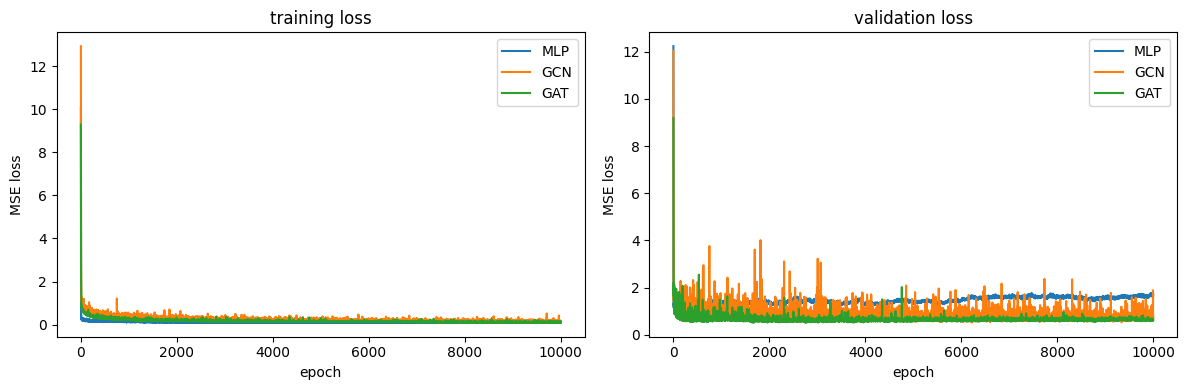

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# train loss
ax1.plot(mlp_history['train_loss'], label='MLP')
ax1.plot(gcn_history['train_loss'], label='GCN')
ax1.plot(gat_history['train_loss'], label='GAT')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.set_title('training loss')
ax1.legend()

# val loss
ax2.plot(mlp_history['val_loss'], label='MLP')
ax2.plot(gcn_history['val_loss'], label='GCN')
ax2.plot(gat_history['val_loss'], label='GAT')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE loss')
ax2.set_title('validation loss')
ax2.legend()

plt.tight_layout()
plt.show()

## predicted vs actual

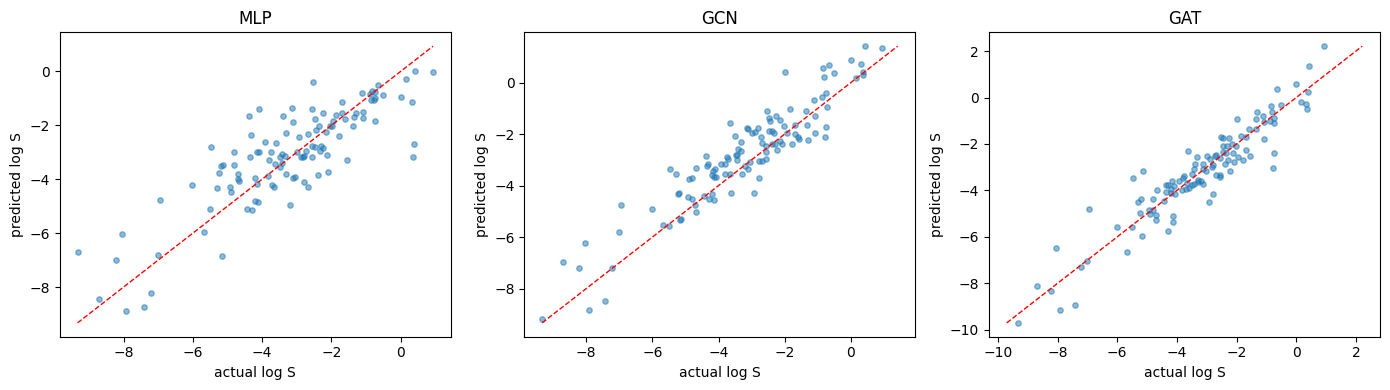

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_preds = [
    (mlp_preds.squeeze().detach().numpy(), y_test.squeeze().numpy(), 'MLP'),
    (gcn_preds.detach().numpy(), gcn_targets.detach().numpy(), 'GCN'),
    (gat_preds.detach().numpy(), gat_targets.detach().numpy(), 'GAT'),
]

for ax, (p, t, name) in zip(axes, all_preds):
    ax.scatter(t, p, alpha=0.5, s=15)
    # diagonal line
    lo = min(t.min(), p.min())
    hi = max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual log S')
    ax.set_ylabel('predicted log S')
    ax.set_title(name)

plt.tight_layout()
plt.show()

## conclusion

all three models were trained with the same architecture size (2 hidden layers, 128 neurons each), the same optimizer (Adam, lr=0.001), and the same 80/10/10 data split. the only difference is the layer type.

results show that **GAT performs best**, followed by **GCN**, with **MLP** performing worst. this supports our hypothesis that preserving molecular graph topology leads to better solubility predictions compared to compressing molecules into fixed-length fingerprint vectors.

the GAT's advantage over the GCN likely comes from its attention mechanism â€” instead of weighting all neighbors equally (like GCN does based on node degree), the GAT learns which neighboring atoms are more important for the prediction. for solubility, this means the model can learn to focus on polar functional groups (like -OH or -NH2) that drive hydrogen bonding with water.

see `extra-insights.ipynb` for attention weight visualizations on specific molecules.